## Work environment

Python 3.6.8 + mpi4py (https://github.com/mpi4py/mpi4py)

This package provides Python bindings for the Message Passing Interface (MPI) standard. It is implemented on top of the MPI specification and exposes an API which grounds on the standard MPI-2 C++ bindings. (https://github.com/mpi4py/mpi4py/blob/master/README.rst)

C++17 + boost mpi

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def py_dir(filename):
    return "./MST_O_logn_logn/" + filename 
    
def cpp_dir(filename):
    return "./MST_O_logn_logn_C-/" + filename 

Prim's algorithm has time complexity $O(n^2)$ where $n = |V|$

For simplicity, the algorithm mentioned in the paper is refered as $A$ here. Suppose $n$ is the number of vertices, where $m$ is the number of machines. The number of edges is $n^2$. Locally, each machine holds $n^2 / m$ edges. The time complexity of of one iteration of the local computation of $A$ is $O((n^2\log{n})/m)$. Because there are $O(\log{\log{n}})$ iterations, the time complexity for local computation is
$$
O(\frac{n^2\log{n}\log{\log{n}}}{m})
$$

# Notes and thoughts

## Python memory usage and simplifying $A$

The size of the full graph is $8n^2$, given that each float64 takes 8 bytes in Numpy. Locally, for holding the graph, each machine locally needs
$$
  \frac{8n^2}{m}
$$
Bytes.
However, the most memory eager construction is the sendbuf during the first step, where each vertex sends edges pointing to other clusters to their cluster leaders. During the first round of the algorithm, each vertex is sending an edge to all the other vertices for the step 1 in the algorithm. Each ClusterEdge instance is a tuple with 3 elements (vertex_from, vertex_to, weight) sized 64 bytes. To send that, each machine needs to construct a buffer sized
$$
  \frac{64n^2}{m}
$$
Bytes During the first round of the original $A$. This is the most memory eager operation in the whole algorithm, But there is a walk around. During the first round, each cluster has size 1 so what rank 0 receives at the end of the iteration is the minimum edge from each vertex. We can skip step 1-3 by sending the minimum edge from each vertex to rank 0 directly.

# 1. Comparing prim's algorithm and $A$

Run time of the prim's compared to $A$ with 1 node 8 takes. The graph is in log scale, graph size vary from $2^4$ to $2^{14}$

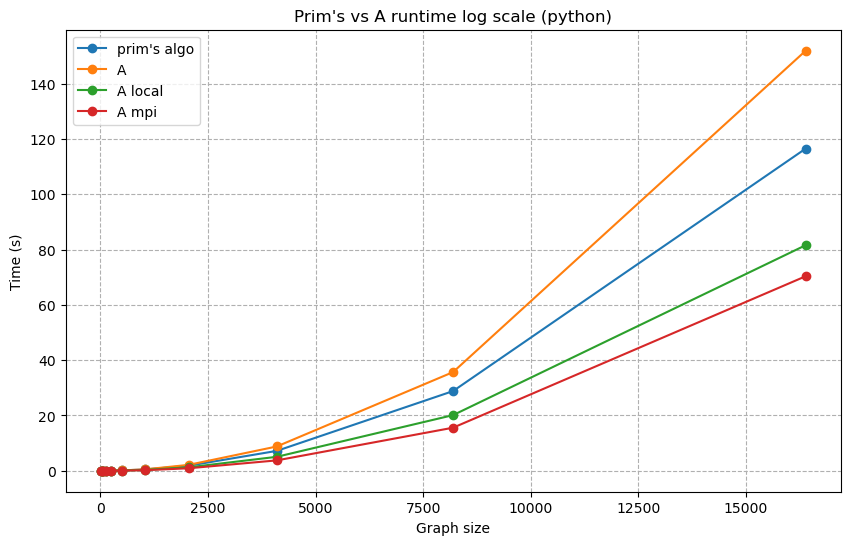

In [3]:
df = pd.read_csv(py_dir('seq_vs_dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_seq'], label="prim's algo", marker='o')
plt.plot(x, df['t_dist'], label='A', marker='o')
plt.plot(x, df['t_dist_seq'], label='A local', marker='o')
plt.plot(x, df['t_dist_mpi'], label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("Prim's vs A runtime log scale (python)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

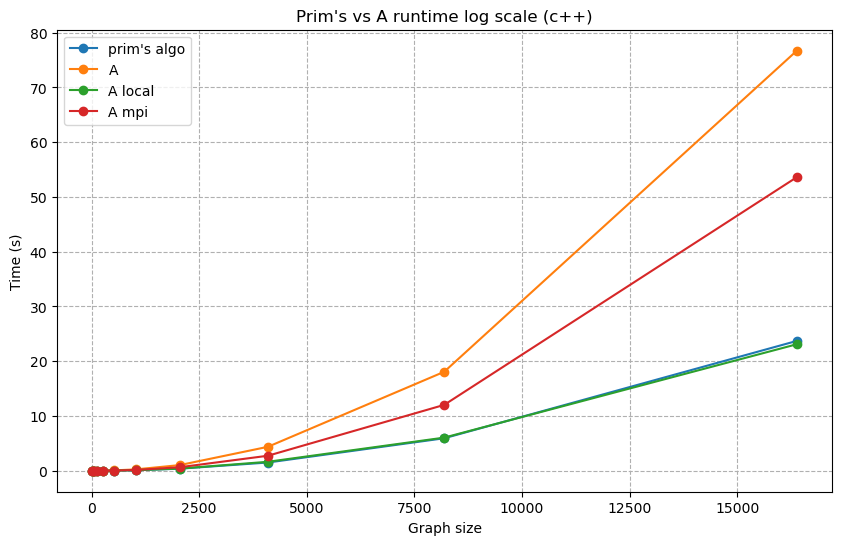

In [4]:
df = pd.read_csv(cpp_dir('seq_vs_dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_prim'], label="prim's algo", marker='o')
plt.plot(x, df['t_mpi'], label='A', marker='o')
plt.plot(x, df['t_mpi_local'], label='A local', marker='o')
plt.plot(x, df['t_mpi_mpi'], label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("Prim's vs A runtime log scale (c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Number of communication rounds of $A$.

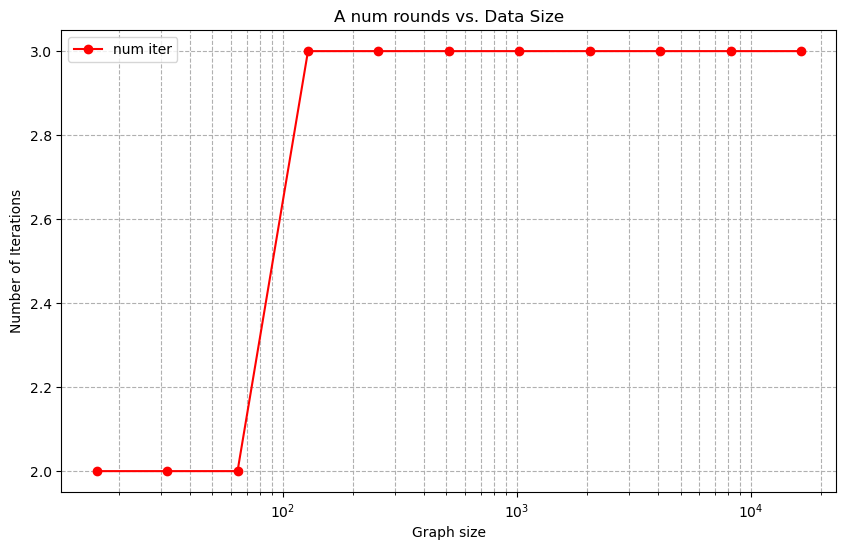

In [6]:
df = pd.read_csv(py_dir('seq_vs_dist_n1_t8.csv'))

plt.figure(figsize=(10, 6))
plt.plot(x, df['k_dist'], label='num iter', marker='o', color='r')

plt.xlabel('Graph size')
plt.ylabel('Number of Iterations')
plt.title('A num rounds vs. Data Size')
plt.xscale('log')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# 2. Running time of $A$

Graph size range from $2^4$ to $2^{15}$ ($1.6 \times 10^4$). Run on 1 node 8 tasks 16G mem for each 

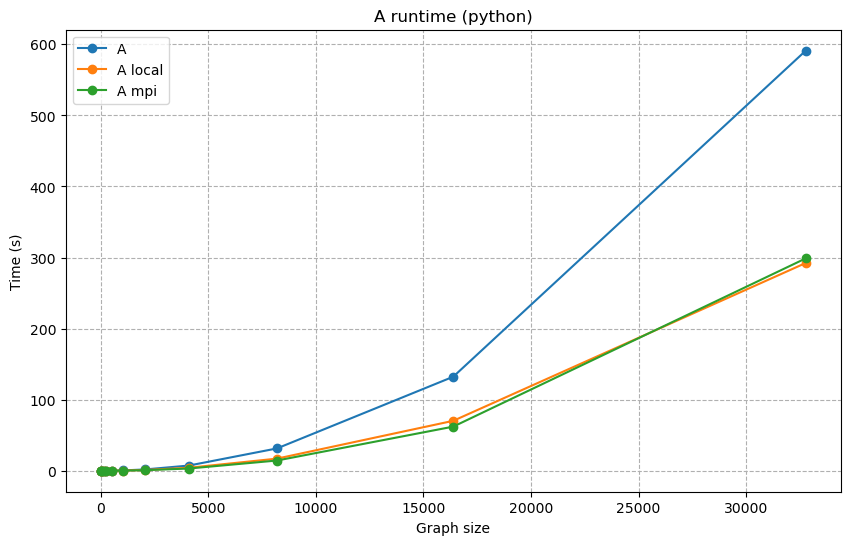

In [7]:
df = pd.read_csv(py_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_dist'], label='A', marker='o')
plt.plot(x, df['t_dist_seq'], label='A local', marker='o')
plt.plot(x, df['t_dist_mpi'], label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title('A runtime (python)')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

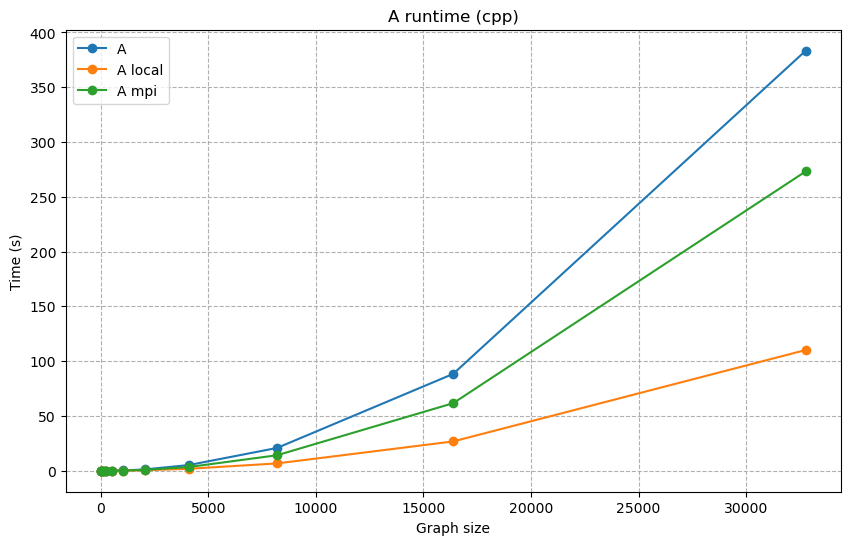

In [8]:
df = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_mpi'], label='A', marker='o')
plt.plot(x, df['t_mpi_local'], label='A local', marker='o')
plt.plot(x, df['t_mpi_mpi'], label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title('A runtime (cpp)')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## Comparing C++ and python running time

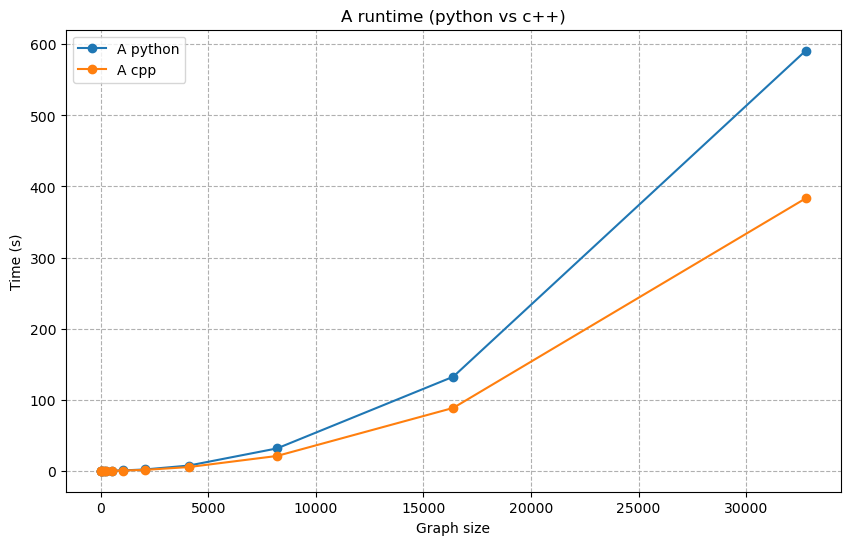

In [9]:
df_py = pd.read_csv(py_dir('dist_n1_t8.csv'))

df_cpp = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df_py['t_dist'], label='A python', marker='o')
# plt.plot(x, df_py['t_dist_seq'], label='A local', marker='o')
# plt.plot(x, df_py['t_dist_mpi'], label='A mpi', marker='o')

plt.plot(x, df_cpp['t_mpi'], label='A cpp', marker='o')
# plt.plot(x, df_cpp['t_mpi_local'], label='A local cpp', marker='o')
# plt.plot(x, df_cpp['t_mpi_mpi'], label='A mpi cpp', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("A runtime (python vs c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Speed up factor (python time / cpp time)

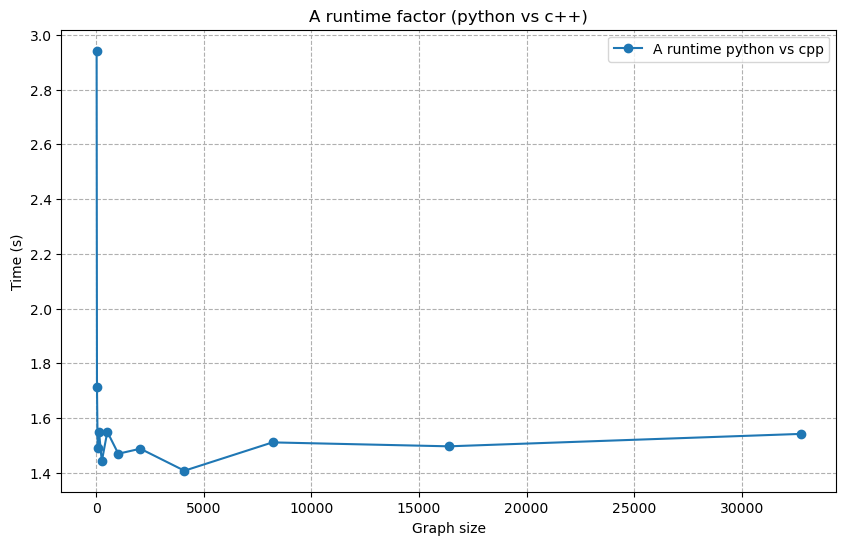

In [12]:
df_py = pd.read_csv(py_dir('dist_n1_t8.csv'))

df_cpp = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df_py['t_dist'] / df_cpp['t_mpi'], label='A runtime python vs cpp', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("A runtime factor (python vs c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Comparing the cpp and python version of the algorithm, cpp version is faster by a factor around 1.5 when the data size is large. When the data size is small, the factor is as large as 3.

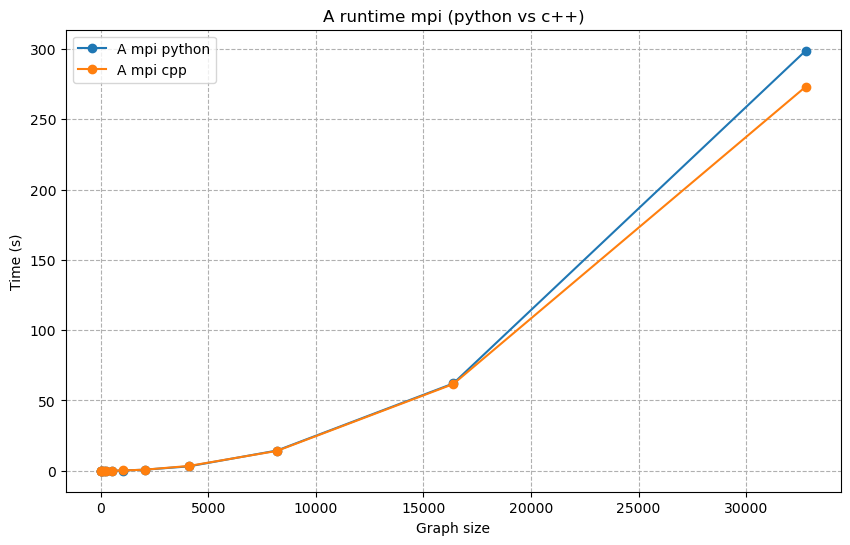

In [11]:
df_py = pd.read_csv(py_dir('dist_n1_t8.csv'))

df_cpp = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df_py['t_dist_mpi'], label='A mpi python', marker='o')

plt.plot(x, df_cpp['t_mpi_mpi'], label='A mpi cpp', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("A runtime mpi (python vs c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

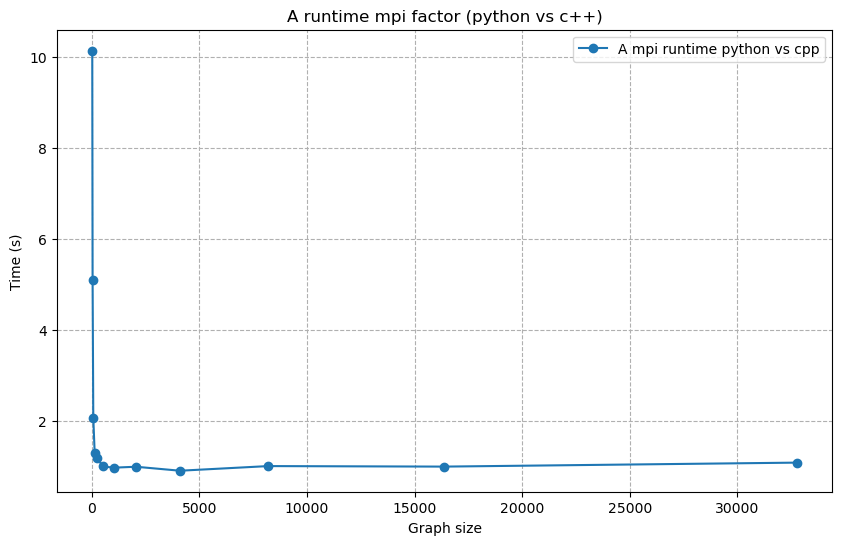

0     10.138833
1      5.095562
2      2.077564
3      1.311403
4      1.185295
5      1.008961
6      0.983407
7      1.003396
8      0.916062
9      1.017876
10     1.006525
11     1.093770
dtype: float64


In [14]:
df_py = pd.read_csv(py_dir('dist_n1_t8.csv'))

df_cpp = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df_py['t_dist_mpi'] / df_cpp['t_mpi_mpi'], label='A mpi runtime python vs cpp', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("A runtime mpi factor (python vs c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print(df_py['t_dist_mpi'] / df_cpp['t_mpi_mpi'])

Where for the mpi running time, when the data size is large, the mpi runtime for the cpp and python is similar. But when the data size is small, the python version is significantly slower than the cpp version. When the data size is small, the slowdown is caused mostly from the cost of invoking the cpp libarary (as mpi4py is a python binding and the invoking cost is constant so takes over). When the data size is large, the slowdown is mostly from marshalling the python data types and memory pattern difference.

https://realpython.com/python-bindings-overview/

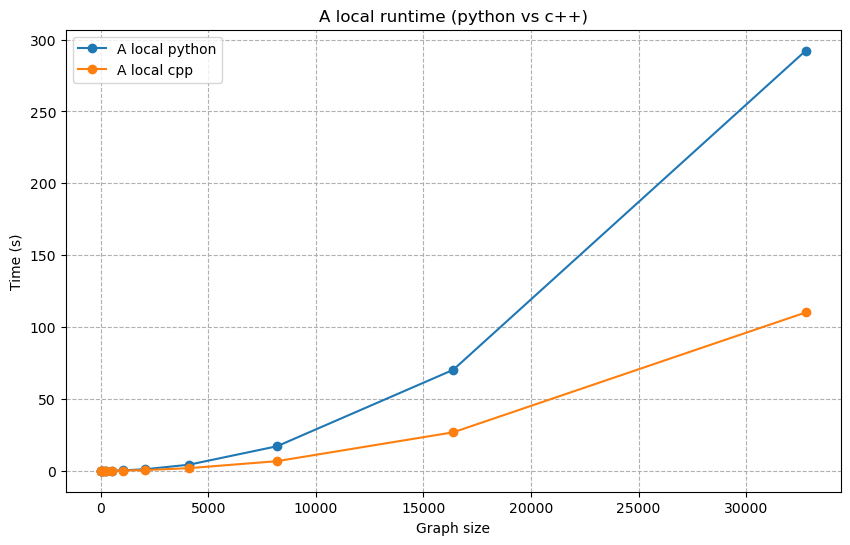

In [15]:
df_py = pd.read_csv(py_dir('dist_n1_t8.csv'))

df_cpp = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df_py['t_dist_seq'], label='A local python', marker='o')

plt.plot(x, df_cpp['t_mpi_local'], label='A local cpp', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("A local runtime (python vs c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

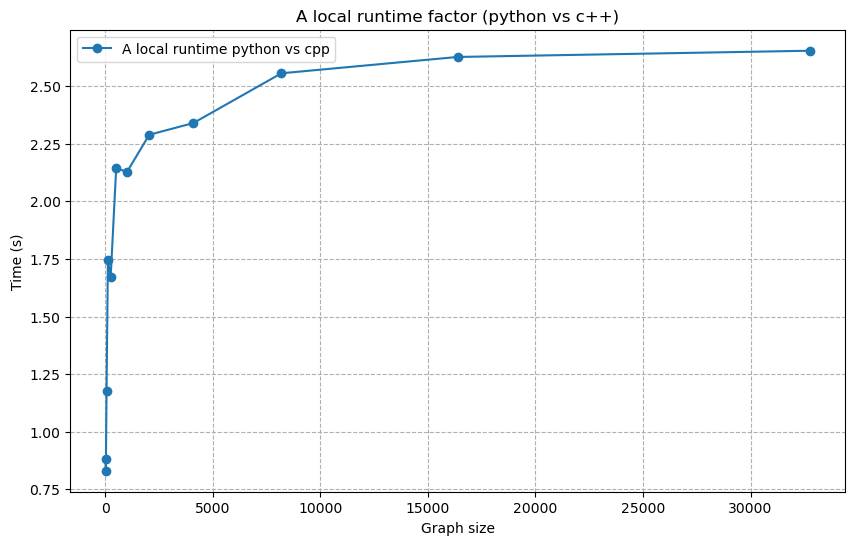

In [17]:
df_py = pd.read_csv(py_dir('dist_n1_t8.csv'))

df_cpp = pd.read_csv(cpp_dir('dist_n1_t8.csv'))

x = np.power(2, (np.arange(len(df)) + 1)) * 8

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df_py['t_dist_seq'] / df_cpp['t_mpi_local'], label='A local runtime python vs cpp', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Time (s)')
plt.title("A local runtime factor (python vs c++)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

The local runtime factor stablize around 2.5-3 as the graph size gets larger, this is mostly from the performance difference between cpp and python

# 3. Stong scaling

The graph size for strong scaling is $2^{15}$

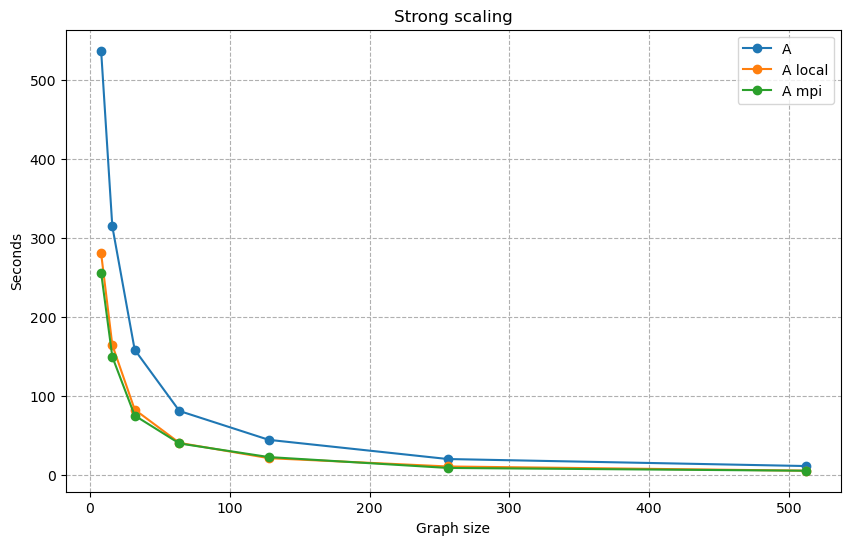

In [9]:
df = pd.read_csv('strong_scaling/strong_scale.csv')

x = np.power(2, (np.arange(len(df)) + 1)) * 4
# 8, 16, 32, ..., 128, 256, 512

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, df['t_dist'], label='A', marker='o')
plt.plot(x, df['t_dist_seq'], label='A local', marker='o')
plt.plot(x, df['t_dist_mpi'], label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Seconds')
plt.title('Strong scaling')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

In [10]:
def get_speed_up(t_arr):
    initial = t_arr[0]
    speedup = 1
    
    result = [speedup]
    
    for i in range(1, len(t_arr)):
        speedup = speedup * (t_arr[i - 1] / t_arr[i])
        result.append(speedup)
        
    return result

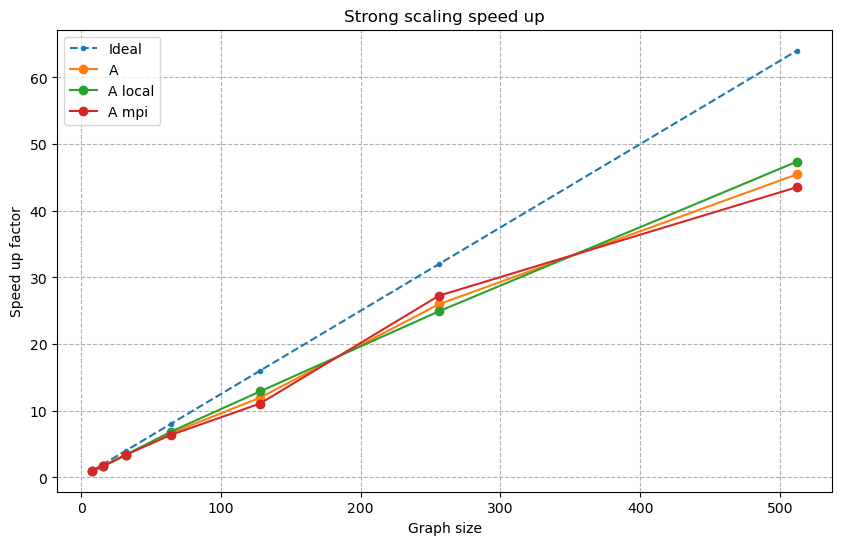

In [11]:
x = np.power(2, (np.arange(len(df)) + 1)) * 4
# 8, 16, 32, ..., 128, 256

ideal_speedup = [2**i for i in range(len(df['t_dist']))]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, ideal_speedup, label='Ideal', marker='.', linestyle="--")
plt.plot(x, get_speed_up(df['t_dist']), label='A', marker='o')
plt.plot(x, get_speed_up(df['t_dist_seq']), label='A local', marker='o')
plt.plot(x, get_speed_up(df['t_dist_mpi']), label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Speed up factor')
plt.title('Strong scaling speed up')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## Strong scaling total computation time

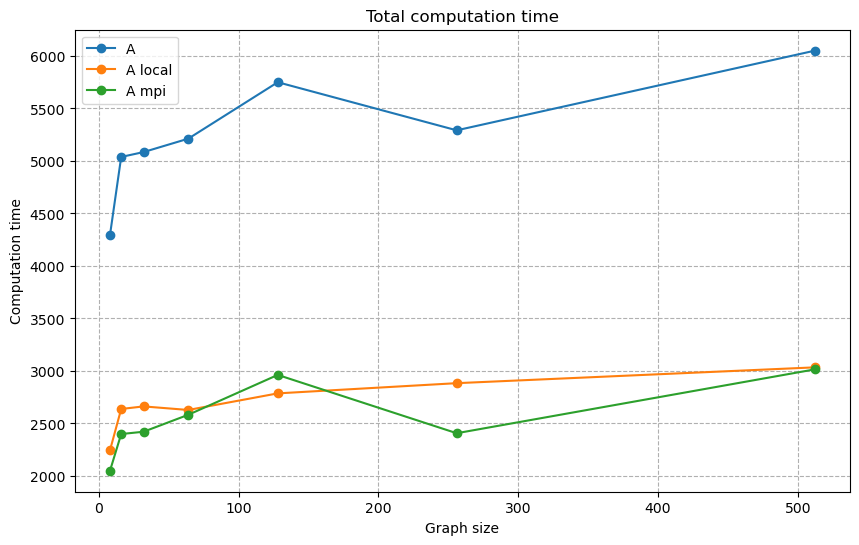

In [14]:
x = np.power(2, (np.arange(len(df)) + 1)) * 4
# 8, 16, 32, ..., 128, 256, 512



# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, x*(df['t_dist'].to_numpy()), label='A', marker='o')
plt.plot(x, x*(df['t_dist_seq'].to_numpy()), label='A local', marker='o')
plt.plot(x, x*(df['t_dist_mpi'].to_numpy()), label='A mpi', marker='o')

plt.xlabel('Graph size')
plt.ylabel('Computation time')
plt.title('Total computation time')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## Note

One thing to mention here is that even the number of communication round stays low (log log n) the algorithm total run time still grow rather fast.

Below is an example of runing time of graph with 32768 vertices and 8 processes. It shows the running time of each iteration of $A$ including the total and detailed running time of mpi in each iteration.

mpi time is the total running time of mpi in one iteration. it is the sum of comm0/1/2/3/4 time.

**comm0** As the algorithm is optimized accoring to how $A$ is simplified at the begining of this document. This time is measured for each vertex to send only the min edge to rank 0, using a MPI_Gather.

**comm1** This measures the time each vertex sends the min edges to the corresponding adjacent cluster leaders, as in step 1 of $A$. This uses MPI_AlltoAll.

**comm2** This measures the time each cluster leader sends the min edges to cluster members (guardian according to the paper) as in the step 2 of $A$. This uses MPI_AlltoAll.

**comm3** This measures the time each guardian send the edge to rank0 in step 3 of $A$. This uses MPI_Gather.

**comm4** This measures the time rank 0 scatter the edges to all the vertices in the graph with MPI_Scatter as in step 4 and 5.

In [35]:
df = pd.read_csv('strong_scaling/strong_scale_t8_4096.csv')

df

,round,time (seconds),mpi time,comm0 time,comm1 time,comm2 time,comm3 time,comm4 time
0,1,0.333585,0.070200,0.04274,0.000000,0.000000,0.000000,0.027460
1,2,381.350939,221.134995,0.00000,96.770867,123.427897,0.805630,0.130600
2,3,155.257385,35.081683,0.00000,9.223262,25.790846,0.062349,0.005227


### Local computation
As seen from section 1 "Comparing prim's algorithm and $A$", for a process (a machine in the conjested clique model), when the local input increases, the running time increases, vice versa. In fact, local computation plays a rather dominant part in the time composition. According to the result of section 3 "Strong scaling", 

### MPI